In [1]:
# Install Real-ESRGAN
%pip install git+https://github.com/xinntao/Real-ESRGAN.git --quiet
%pip install basicsr facexlib gfpgan --quiet

print("✅ Real-ESRGAN installed")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ Real-ESRGAN installed


In [2]:
import types
import torchvision.transforms.functional as F
import sys

module = types.ModuleType("torchvision.transforms.functional_tensor")
module.rgb_to_grayscale = F.rgb_to_grayscale
sys.modules["torchvision.transforms.functional_tensor"] = module

In [3]:
# ================================================
# Notebook 3: EasyOCR + Real-ESRGAN Super Resolution + Line Segmentation
# ================================================

import easyocr
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import os
from pathlib import Path

# Initialize Real-ESRGAN
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
# Cell: Load Super-Resolution Model
print("⏳ Loading Real-ESRGAN model...")

model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
upsampler = RealESRGANer(
    scale=4,
    model_path='https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth',
    model=model,
    tile=400,                  # Important for large images
    tile_pad=10,
    pre_pad=0,
    half=True if torch.cuda.is_available() else False
)

print("✅ Real-ESRGAN loaded!")

⏳ Loading Real-ESRGAN model...
Downloading: "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth" to c:\Users\Avilasha\Desktop\handwriting-ocr\cuda_env\Lib\site-packages\weights\RealESRGAN_x4plus.pth



100%|██████████| 63.9M/63.9M [00:13<00:00, 5.05MB/s]
c:\Users\Avilasha\Desktop\handwriting-ocr\cuda_env\Lib\site-packages\realesrgan\utils.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

✅ Real-ESRGAN loaded!


In [5]:
# Cell: Enhanced Preprocessing with Super-Resolution
def preprocess_with_sr(image_path, show_steps=False):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    # Step 1: Super-Resolution (4x upscale)
    print("🔍 Applying Super-Resolution (4x)...")
    sr_img, _ = upsampler.enhance(img, outscale=4)
    
    # Step 2: Convert to grayscale + strong enhancement
    gray = cv2.cvtColor(sr_img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    
    # Sharpening
    sharpened = cv2.addWeighted(enhanced, 2.5, cv2.GaussianBlur(enhanced, (0,0), 3), -1.5, 0)
    
    # Final binary
    thresh = cv2.adaptiveThreshold(sharpened, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 11, 2)
    
    if show_steps:
        plt.figure(figsize=(15, 8))
        plt.subplot(1,3,1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.subplot(1,3,2)
        plt.imshow(cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB))
        plt.title("After Super-Resolution")
        plt.subplot(1,3,3)
        plt.imshow(thresh, cmap='gray')
        plt.title("Final Preprocessed")
        plt.show()
    
    return thresh, sr_img

In [6]:
# Cell: Recognition with Line Segmentation + Zoom
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

def recognize_text(image_path):
    processed, sr_img = preprocess_with_sr(image_path, show_steps=True)
    
    # Find lines
    contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])
    
    recognized_lines = []
    
    for i, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)
        if h < 30 or w < 80:
            continue
            
        crop = processed[y:y+h, x:x+w]
        # Extra zoom on each line
        zoomed = cv2.resize(crop, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
        
        result = reader.readtext(zoomed, detail=1, paragraph=False)
        
        for detection in result:
            text = detection[1].strip()
            conf = detection[2]
            if len(text) > 3 and conf > 0.35:
                recognized_lines.append(text)
                print(f"Line {i+1}: {text} (Conf: {conf:.3f})")
    
    final_text = "\n".join(recognized_lines)
    
    print("\n" + "="*90)
    print("✅ FINAL RECOGNIZED TEXT:")
    print("="*90)
    print(final_text)
    print("="*90)
    
    return final_text

Processing: 1_3xUyINxRtDf2qowd-kkGQA.jpg
🔍 Applying Super-Resolution (4x)...
	Tile 1/16
	Tile 2/16
	Tile 3/16
	Tile 4/16
	Tile 5/16
	Tile 6/16
	Tile 7/16
	Tile 8/16
	Tile 9/16
	Tile 10/16
	Tile 11/16
	Tile 12/16
	Tile 13/16
	Tile 14/16
	Tile 15/16
	Tile 16/16


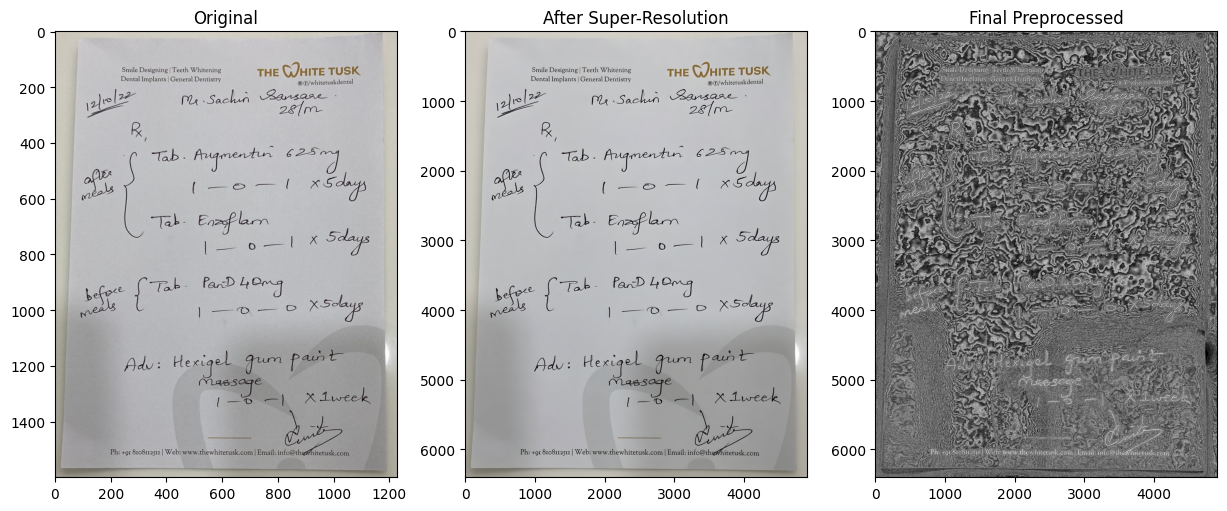

Line 5088: eth Whitening (Conf: 0.804)
Line 5088: eral Dentistry (Conf: 0.708)
Line 5088: /whutetuskdental (Conf: 0.620)
Line 11217: Spile Designing (Conf: 0.622)
Line 11217: Teeth Whutening (Conf: 0.792)
Line 11217: Dental Implants (Conf: 0.944)
Line 11217: General Dentistry (Conf: 0.959)
Line 11217: Iwhutetuskdental (Conf: 0.377)
Line 11217: Sachlo (Conf: 0.658)
Line 11217: 28/n (Conf: 0.398)
Line 11217: 810812511 (Conf: 0.669)
Line 11217: thewbitetusk com (Conf: 0.536)
Line 11217: Email: info@chexhitecusk com (Conf: 0.566)
Line 49096: Teeth Whi (Conf: 0.989)
Line 49096: General Den (Conf: 0.643)
Line 49822: )esio (Conf: 0.893)
Line 49896: Jhiteni (Conf: 0.454)
Line 49896: Dentst (Conf: 0.562)
Line 50316: ning (Conf: 0.550)
Line 50316: ants (Conf: 0.696)
Line 50711: teni (Conf: 0.866)
Line 52229: Dental Implants (Conf: 0.992)
Line 54879: whutetuskdental (Conf: 0.685)
Line 60240: vhitet (Conf: 0.895)
Line 467238: o@chexvhitecusk (Conf: 0.482)
Line 487406: TOQ, (Conf: 0.691)
Line 49462

In [7]:
# Cell: Test
image_path = r"C:\Users\Avilasha\Desktop\handwriting-ocr\input_images\1_3xUyINxRtDf2qowd-kkGQA.jpg"   # Change this

print(f"Processing: {Path(image_path).name}")
text = recognize_text(image_path)

with open("recognized_text.txt", "w", encoding="utf-8") as f:
    f.write(text)

print("✅ Result saved to recognized_text.txt")